## 10 PUNTOS EXTRAS

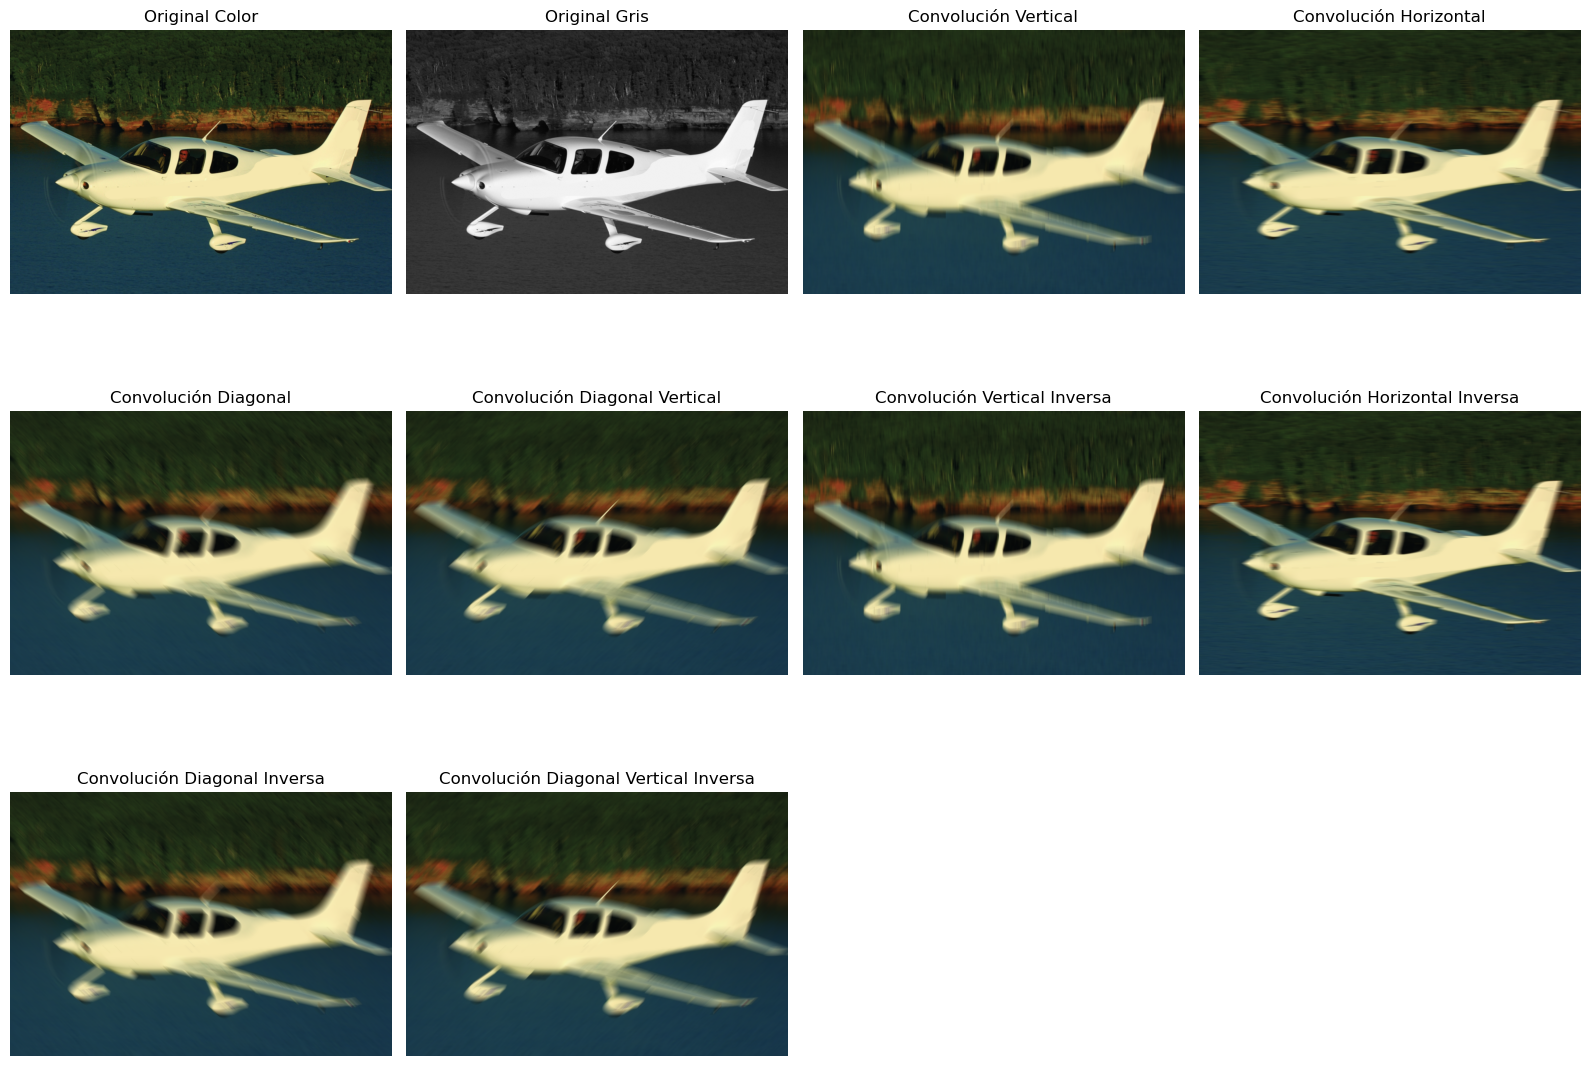

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def crear_kernel_direccional(tamano, direccion, inverso=False):
 
    if tamano % 2 == 0:
        raise ValueError("El tamaño del kernel debe ser impar.")

    kernel = np.zeros((tamano, tamano), dtype=np.float32)

    if direccion == 'vertical':
        kernel[:, tamano // 2] = 1

    elif direccion == 'horizontal':
        kernel[tamano // 2, :] = 1

    elif direccion == 'diagonal':
        np.fill_diagonal(kernel, 1)

    elif direccion == 'diagonal_inversa':
        kernel = np.fliplr(np.eye(tamano, dtype=np.float32))

    else:
        raise ValueError("Dirección no válida.")


    if inverso:
        kernel = np.flip(kernel)


    kernel /= np.sum(kernel)
    return kernel


def aplicar_convolucion(imagen, kernel):
    return cv2.filter2D(
        imagen,
        ddepth=-1,
        kernel=kernel,
        borderType=cv2.BORDER_REFLECT
    )


ruta_imagen = 'avion.jpg' 
img = cv2.imread(ruta_imagen)

if img is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

tam_kernel = 15

kernel_vertical = crear_kernel_direccional(tam_kernel, 'vertical')
kernel_horizontal = crear_kernel_direccional(tam_kernel, 'horizontal')
kernel_diagonal = crear_kernel_direccional(tam_kernel, 'diagonal')
kernel_diagonal_inv = crear_kernel_direccional(tam_kernel, 'diagonal_inversa')


kernel_vertical_inv = crear_kernel_direccional(tam_kernel, 'vertical', inverso=True)
kernel_horizontal_inv = crear_kernel_direccional(tam_kernel, 'horizontal', inverso=True)
kernel_diagonal_inv2 = crear_kernel_direccional(tam_kernel, 'diagonal', inverso=True)
kernel_diagonal_inv_inv = crear_kernel_direccional(tam_kernel, 'diagonal_inversa', inverso=True)


resultados = [
    ("Vertical", aplicar_convolucion(img_rgb, kernel_vertical)),
    ("Horizontal", aplicar_convolucion(img_rgb, kernel_horizontal)),
    ("Diagonal", aplicar_convolucion(img_rgb, kernel_diagonal)),
    ("Diagonal Vertical", aplicar_convolucion(img_rgb, kernel_diagonal_inv)),
    ("Vertical Inversa", aplicar_convolucion(img_rgb, kernel_vertical_inv)),
    ("Horizontal Inversa", aplicar_convolucion(img_rgb, kernel_horizontal_inv)),
    ("Diagonal Inversa", aplicar_convolucion(img_rgb, kernel_diagonal_inv2)),
    ("Diagonal Vertical Inversa", aplicar_convolucion(img_rgb, kernel_diagonal_inv_inv)),
]


plt.figure(figsize=(16, 12))


plt.subplot(3, 4, 1)
plt.imshow(img_rgb)
plt.title("Original Color")
plt.axis('off')


plt.subplot(3, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Gris")
plt.axis('off')


for i, (titulo, imagen) in enumerate(resultados, start=3):
    plt.subplot(3, 4, i)
    plt.imshow(imagen)
    plt.title(f"Convolución {titulo}")
    plt.axis('off')

plt.tight_layout()
plt.show()